In [65]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoModelForCausalLM, AutoTokenizer, logging

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [15]:
# Import Pythia - 2.8B from Eleuther
logging.set_verbosity_error()

tokenizer = AutoTokenizer.from_pretrained("EleutherAI/pythia-2.8b")
model = AutoModelForCausalLM.from_pretrained("EleutherAI/pythia-2.8b").to(device)

model.eval()
num_layers = model.config.num_hidden_layers
num_heads = model.config.num_attention_heads
head_size = model.config.hidden_size // num_heads


print(f"Number of layers: {num_layers}")
print(f"Number of heads: {num_heads}")
print(f"Head size: {head_size}")
#

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

Number of layers: 32
Number of heads: 32
Head size: 80


# Implant hooks on qkv layer of attention block

In [18]:
# Hook function
activations = {}
def hook(layeri):
  def hook_fn(module, input, output):
    hook_name = f'attn_{layeri}'
    activations[hook_name] = output
    return None
  return hook_fn

# Implant hooks for all layers
if "hook_handle" in globals():
  for h in hook_handle:
    h.remove()

hook_handle = []

for layeri in range(num_layers):
  hook_handle.append(model.gpt_neox.layers[layeri].attention.query_key_value.register_forward_hook(hook(layeri)))


# Import text and pass it through the model

In [19]:
# Import text
# https://en.wikipedia.org/wiki/Fiji
txt = "The majority of Fiji's islands were formed by volcanic activity starting around 150 million years ago. Some geothermal activity still occurs today on the islands of Vanua Levu and Taveuni."

# tokenize text
tokens = tokenizer(txt, return_tensors="pt").to(device)
num_tokens = len(tokens["input_ids"][0])

# pass through model
with torch.no_grad():
  outputs = model(**tokens)

In [21]:
activations.keys(), activations['attn_3'].shape

(dict_keys(['attn_0', 'attn_1', 'attn_2', 'attn_3', 'attn_4', 'attn_5', 'attn_6', 'attn_7', 'attn_8', 'attn_9', 'attn_10', 'attn_11', 'attn_12', 'attn_13', 'attn_14', 'attn_15', 'attn_16', 'attn_17', 'attn_18', 'attn_19', 'attn_20', 'attn_21', 'attn_22', 'attn_23', 'attn_24', 'attn_25', 'attn_26', 'attn_27', 'attn_28', 'attn_29', 'attn_30', 'attn_31']),
 torch.Size([1, 39, 7680]))

In [38]:
# Separate Q,K,V matrices for layer 14
Q, K, V = torch.split(activations['attn_13'][0], model.config.hidden_size, dim=1)
print(f'Q_shape: {Q.shape}')

# Split the Q matrix into number of heads
Q_h = torch.split(Q, head_size, dim=1)
print(f'Q_h_shape: {Q_h[0].shape}')

print(f'There are {len(Q_h)} heads')

Q_shape: torch.Size([39, 2560])
Q_h_shape: torch.Size([39, 80])
There are 32 heads


# Laminar profile of attention head distributions

In [62]:
# Seprate Q and K
Q, K, _ = torch.split(activations[f'attn_{layeri}'][0], model.config.hidden_size, dim=1)

# Split Q and K by number of attention heads
Q_h = torch.split(Q, head_size, dim=1)
K_h = torch.split(K, head_size, dim=1)

Q_h[0].shape, K_h[0].shape

attn_scores = torch.matmul(Q_h[0], K_h[0].T) / torch.sqrt(torch.tensor(head_size))
past_mask = torch.tril(torch.ones(num_tokens, num_tokens)).bool().to(device)
attn_scores.masked_fill_(~past_mask, float('-inf'))

torch.diag(F.softmax(attn_scores, dim=-1)[1:,1:]).shape

torch.Size([38])

In [66]:
sqrt_attn_head_dim = torch.sqrt(torch.tensor(head_size))

smx = np.linspace(0, 1, 300)
head_distributions = np.zeros((num_layers, len(smx), 2)) # 0 - attention for the final token with all previous tokens, 1 - self attention for final token

for layeri in range(num_layers):

  # Seprate Q and K
  Q, K, _ = torch.split(activations[f'attn_{layeri}'][0], model.config.hidden_size, dim=1)

  # Split Q and K by number of attention heads
  Q_h = torch.split(Q, head_size, dim=1)
  K_h = torch.split(K, head_size, dim=1)

  # Initialize
  final_to_prev = np.array([])
  self_attn = np.array([])

  # Calculate attention
  for i in range(num_heads):

    # Calculate raw attention scores with mask
    attn_scores = torch.matmul(Q_h[i], K_h[i].T) / sqrt_attn_head_dim
    past_mask = torch.tril(torch.ones(num_tokens, num_tokens)).bool().to(device)
    attn_scores.masked_fill_(~past_mask, float('-inf'))

    # Calculate softmax
    attn_sm = F.softmax(attn_scores, dim=-1)

    # Attention weights of final token attending to all previous tokens (excluding itself)
    f2p = attn_sm[-1,:-1].cpu().numpy()

    # Self attention for the all tokens excluding the first token
    sa = torch.diag(attn_sm[1:,1:]).cpu().numpy()

    # Add to the corresponding arrays
    final_to_prev = np.concatenate((final_to_prev, f2p))
    self_attn = np.concatenate((self_attn, sa))

  # Calculate Gaussain KDE for layeri
  y = stats.gaussian_kde(final_to_prev)(smx)
  head_distributions[layeri, :, 0] = y / y.max()

  y = stats.gaussian_kde(self_attn)(smx)
  head_distributions[layeri, :, 1] = y/ y.max()

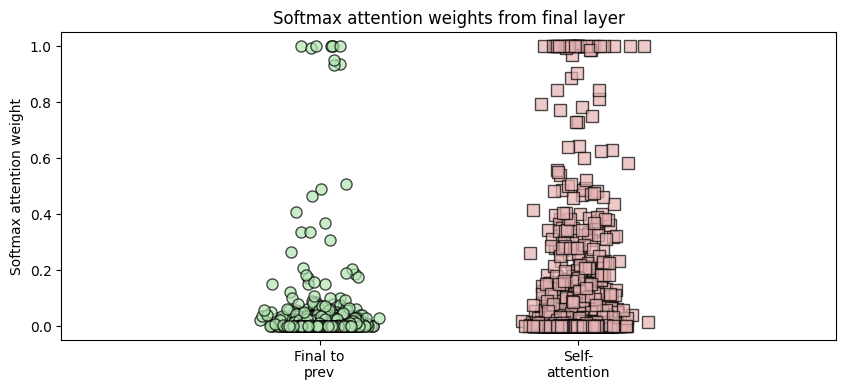

In [68]:
## visualize one layer
plt.figure(figsize=(10,4))

plt.plot(np.random.randn(len(final_to_prev))/70 - .1,final_to_prev,'ko',markerfacecolor=[.7,.9,.7,.7],markersize=8)
plt.plot(np.random.randn(len(self_attn))/70 + .1,self_attn,'ks',markerfacecolor=[.9,.7,.7,.7],markersize=8)

plt.gca().set(xticks=[-.1,.1],xlim=[-.3,.3],xticklabels=['Final to\nprev','Self-\nattention',],
              ylabel='Softmax attention weight',title='Softmax attention weights from final layer')

plt.show()

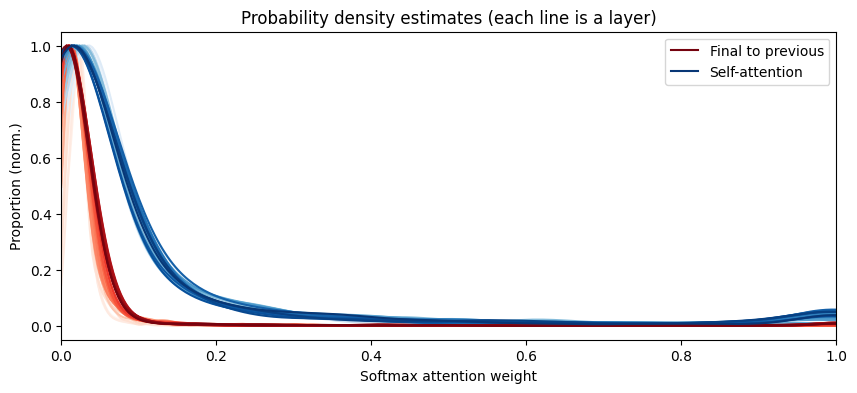

In [69]:
# show all lines in one plot
plt.figure(figsize=(10,4))

# plot all the lines
for i in range(num_layers):

  # special case for final layer to get the legend
  if i==num_layers-1:
    plt.plot(smx,head_distributions[i,:,0],color=mpl.cm.Reds(i/32),label='Final to previous')
    plt.plot(smx,head_distributions[i,:,1],color=mpl.cm.Blues(i/32),label='Self-attention')
  else:
    plt.plot(smx,head_distributions[i,:,0],color=mpl.cm.Reds(i/32))
    plt.plot(smx,head_distributions[i,:,1],color=mpl.cm.Blues(i/32))


plt.legend()
plt.gca().set(xlim=[0,1],xlabel='Softmax attention weight',ylabel='Proportion (norm.)',
              title='Probability density estimates (each line is a layer)')
plt.show()

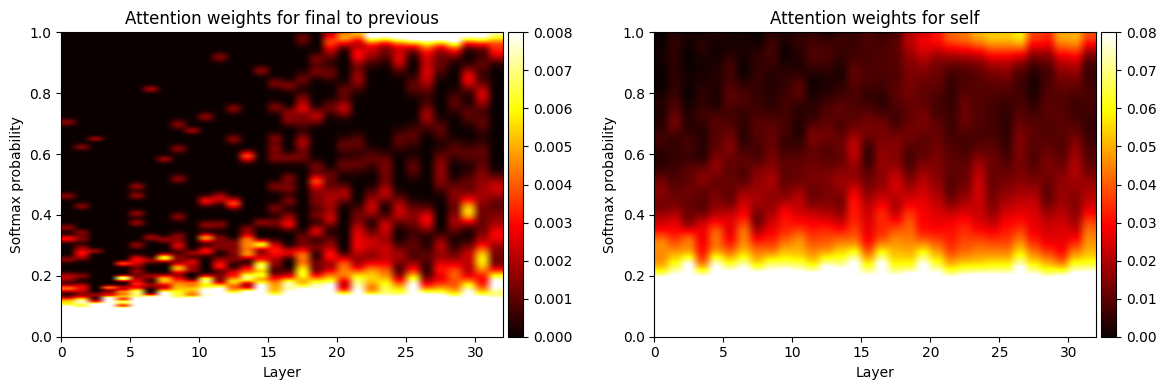

In [73]:
# heatmaps of layers and probabilities
fig,axs = plt.subplots(1,2,figsize=(12,4))

# final2prev
h = axs[0].imshow(head_distributions[:,:,0].T,aspect='auto',origin='lower',vmin=0,vmax=.008,cmap='hot',
                  extent=[0,num_layers,smx[0],smx[-1]])
fig.colorbar(h,ax=axs[0],pad=.01)
axs[0].set(ylabel='Softmax probability',xlabel='Layer',title='Attention weights for final to previous')

# self-attention
h = axs[1].imshow(head_distributions[:,:,1].T,aspect='auto',origin='lower',vmin=0,vmax=.08,cmap='hot',
                  extent=[0,num_layers,smx[0],smx[-1]])
fig.colorbar(h,ax=axs[1],pad=.01)
axs[1].set(ylabel='Softmax probability',xlabel='Layer',title='Attention weights for self')

plt.tight_layout()
plt.show()

# Get the token pairs that has the maximum influence

In [80]:
import math
import pandas as pd
import torch
import torch.nn.functional as F

def collect_next_token_pairs_attn_value(
    activations,
    tokens,
    tokenizer,
    model,
    topk_per_head=3,
    include_self=False,
    decode_tokens=True,
):
    device = tokens["input_ids"].device
    num_layers = model.config.num_hidden_layers
    num_heads = model.config.num_attention_heads
    hidden_size = model.config.hidden_size
    head_size = hidden_size // num_heads
    sqrt_d = math.sqrt(head_size)

    token_ids = tokens["input_ids"][0]
    seq_len = token_ids.shape[0]

    if decode_tokens:
        token_text = [tokenizer.decode([tid.item()]) for tid in token_ids]
    else:
        token_text = tokenizer.convert_ids_to_tokens(token_ids)

    past_mask = torch.tril(
        torch.ones(seq_len, seq_len, device=device, dtype=torch.bool)
    )

    rows = []

    for layeri in range(num_layers):
        qkv = activations[f'attn_{layeri}'][0]   # (seq_len, 3*hidden)
        Q, K, V = torch.split(qkv, hidden_size, dim=1)

        Q_h = torch.split(Q, head_size, dim=1)
        K_h = torch.split(K, head_size, dim=1)
        V_h = torch.split(V, head_size, dim=1)

        for head in range(num_heads):
            attn_scores = Q_h[head] @ K_h[head].T / sqrt_d
            attn_scores = attn_scores.masked_fill(~past_mask, float("-inf"))
            attn_sm = F.softmax(attn_scores, dim=-1)

            if include_self:
                final_attn = attn_sm[-1, :]
                value_norms = torch.norm(V_h[head], dim=1)
                candidate_indices = torch.arange(seq_len, device=device)
            else:
                final_attn = attn_sm[-1, :-1]
                value_norms = torch.norm(V_h[head][:-1], dim=1)
                candidate_indices = torch.arange(seq_len - 1, device=device)

            score = final_attn * value_norms
            k = min(topk_per_head, score.numel())
            vals, idx_local = torch.topk(score, k=k)

            for rank, (s, j_local) in enumerate(zip(vals, idx_local), start=1):
                j = candidate_indices[j_local].item()
                rows.append({
                    "layer": layeri,
                    "head": head,
                    "rank_in_head": rank,
                    "query_index": seq_len - 1,
                    "query_token": token_text[-1],
                    "key_index": j,
                    "key_token": token_text[j],
                    "attn": float(final_attn[j_local].item()),
                    "value_norm": float(value_norms[j_local].item()),
                    "score": float(s.item()),
                })

    df = pd.DataFrame(rows)
    df = df.sort_values(
        ["score", "attn"], ascending=[False, False]
    ).reset_index(drop=True)
    return df

In [82]:
df_pairs = collect_next_token_pairs_attn_value(
    activations=activations,
    tokens=tokens,
    tokenizer=tokenizer,
    model=model,
    topk_per_head=3,
    include_self=False,
    decode_tokens=True,
)

show_cols = [
    "layer", "head", "rank_in_head",
    "query_index", "query_token",
    "key_index", "key_token",
    "attn", "value_norm", "score"
]

print(df_pairs[show_cols].head(40).to_string(index=False))

 layer  head  rank_in_head  query_index query_token  key_index key_token     attn  value_norm   score
    27    24             1           38           .         23     still 0.943848     420.000 396.500
    29    12             1           38           .         20        ge 0.999512     366.000 365.750
    26    21             1           38           .         13    around 0.912598     375.250 342.500
    28     6             1           38           .         17       ago 0.986328     341.500 336.750
    28    24             1           38           .         13    around 0.961426     342.250 329.000
    28    18             1           38           .         35         T 0.966797     319.500 309.000
    30    30             1           38           .         36       ave 0.989746     307.250 304.000
    26    30             1           38           .          4       iji 0.987305     306.500 302.500
    28    30             1           38           .         35         T 0.999512 

In [83]:
token_summary = (
    df_pairs.groupby(["key_index", "key_token"], as_index=False)
            .agg(
                count=("key_token", "size"),
                mean_attn=("attn", "mean"),
                max_attn=("attn", "max"),
                mean_score=("score", "mean"),
                max_score=("score", "max"),
            )
            .sort_values(["count", "max_score"], ascending=[False, False])
)

print(token_summary.head(20).to_string(index=False))

 key_index key_token  count  mean_attn  max_attn  mean_score  max_score
         1  majority    178   0.119074  1.000000    2.786762   57.84375
        16     years    169   0.164586  1.000000    7.930960  223.12500
        36       ave    122   0.196372  1.000000   21.149951  304.00000
         0       The    121   0.024338  0.324707    0.615982   38.46875
        17       ago    120   0.162730  1.000000    9.175783  336.75000
        37       uni    118   0.118575  0.932617    2.745286   52.81250
        15   million    117   0.122451  1.000000    9.301165  194.25000
        32       Lev    116   0.134522  1.000000    8.786479  241.87500
         2        of    109   0.179053  1.000000    4.717204   93.25000
        31        ua    104   0.128966  0.825195    6.869445  139.12500
        33         u     92   0.101311  1.000000    2.485085   43.56250
        23     still     82   0.152574  1.000000    8.969090  396.50000
        19      Some     82   0.146737  1.000000    2.413673   3